# Graph Neural Networks
**Author:** Darrick Lee

In this notebook, we will use Pytorch Geometric (PyG), which is a library built on top of Pytorch, to build and train graph neural networks.

This notebook was written by following some of the tasks in the following (excellent) tutorials, take a look at these if you'd like further exercises to do:
- [Official PyG Notebook Tutorials (notebooks 2-3)](https://pytorch-geometric.readthedocs.io/en/latest/get_started/colabs.html)
- [Geometric Deep Learning Course (Tutorial 1)](https://geometricdeeplearning.com/lectures/)

### Installation
For this notebook, the only package we need to install is the `pytorch-geometric` library. In your terminal, activate your agq-env environment and install this library using `pip`:

`pip install torch-geometric`


### Parts of this notebook
1) **Working with Graphs**: Look and some examples of working with graph data computationally.    

2) **Node Classification with Cora**: Here, we look at the Cora citation network dataset, and study a node classification task. We will compare an ordinary MLP (without using the graph structure) with the graph convolutional network (GCN).
3) **Graph Classification with Zinc**: Here, we look at the ZINC dataset. This is a dataset of 12,000 molecular graphs (nodes represent atoms, edges represent bonds). Each molecule (graph) comes with a real-valued molecular property. Our aim here is to estimate this molecular property from the graph using a GCN. Due to the larger dataset, we will need to work with mini-batching.

**Parts 2(a-d) will be marked as the second part of Homework 5. They are due on GitHub by 12pm on Friday, 3 April.**

| <p align='left'> Exercise                | <p align='left'> Marks possible |  <p align='left'> Marks awarded |
| ------------------------------------- | --- | --- |
| <p align='left'> 1a. Edge index to adjacency matrix  | <p align='left'> -- | -- |
| <p align='left'> 1b. Computing degrees from an edge index   | <p align='left'> -- | -- |
| <p align='left'> 1c. Neighborhood aggregation by hand  | <p align='left'> -- | -- |
| <p align='left'> 1d. Analyze the Cora graph | <p align='left'> -- | -- |
| <p align='left'> 2a. Build a Cora MLP   | <p align='left'> 1 |  |
| <p align='left'> 2b. Define the loss function  | <p align='left'> 1 |  |
| <p align='left'> 2c. Define a GCN layer  | <p align='left'> 2 |  |
| <p align='left'> 2d. Build a 2-layer GCN  | <p align='left'> 1 |  |
| <p align='left'> 3a. Visualize the ZINC dataset  | <p align='left'> -- | -- |
| <p align='left'> 3b. Build a GCN for graph regression  | <p align='left'> -- | -- |
| <p align='left'> **Total** | <p align='left'> max **5** | |

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

from torch_geometric.data import Data
from torch_geometric.utils import to_networkx

C:\Users\3010295H\AppData\Local\anaconda3\envs\agq-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Helper function for visualizing a PyG graph
def visualize_graph(data, color=None, labels=None):
    G = to_networkx(data, to_undirected=True)
    pos = nx.spring_layout(G, seed=2, scale=0.8)

    fig, ax = plt.subplots(figsize=(7,7))
    ax.set_xticks([])
    ax.set_yticks([])
    ax.margins(0.2)

    draw_kwargs = {"pos": pos, "with_labels": False, "ax": ax}
    if color is not None:
        draw_kwargs.update({"node_color": color, "cmap": "Set2"})
    nx.draw_networkx(G, **draw_kwargs)

    if labels is not None:
        if hasattr(labels, "detach"):
            labels = labels.detach().cpu()

        node_labels = {}
        for i, value in enumerate(labels):
            if hasattr(value, "tolist"):
                value = value.tolist()
            node_labels[i] = value if isinstance(value, str) else str(value)

        label_pos = {node: (x, y + 0.08) for node, (x, y) in pos.items()}
        nx.draw_networkx_labels(G, pos=label_pos, labels=node_labels, font_size=10, ax=ax)

    plt.show()

## Part 1: Working with Graphs

In PyTorch Geometric (PyG), a graph is stored as an **edge index list**: a $2 \times m$ integer tensor where $m$ is the number of (directed) edges. The first row contains source nodes and the second row contains target nodes.

For example, consider the path graph $0 - 1 - 2 - 3$. Since PyG treats edges as directed, we include both directions:

In [3]:
# Path graph: 0 - 1 - 2 - 3
# Each undirected edge {i,j} is stored as two directed edges (i,j) and (j,i).
edge_index = torch.tensor([
    [0, 1, 1, 2, 2, 3],  # source nodes
    [1, 0, 2, 1, 3, 2],  # target nodes
], dtype=torch.long)

print("Edge index shape:", edge_index.shape)
print("Number of directed edges:", edge_index.shape[1])
print(edge_index)

Edge index shape: torch.Size([2, 6])
Number of directed edges: 6
tensor([[0, 1, 1, 2, 2, 3],
        [1, 0, 2, 1, 3, 2]])


### Exercise 1a: Edge index to adjacency matrix

Write a function that converts an edge index tensor to an adjacency matrix.  

*Question:* Why do we need to include the number of nodes `n` as an input? *Answer:* To account for any nodes which are not connected to any other nodes.

*Hint:* Create a zero matrix of the right size, then set the appropriate entries to 1. You can determine the number of nodes from the maximum index in `edge_index`.

In [27]:
def edge_index_to_adjacency(edge_index, n):
    """
    Convert a (2, m) edge index tensor to an (n, n) adjacency matrix.
    """
    adj_matrix = torch.zeros((n,n))
    
    for i in range(edge_index.shape[1]):
        adj_matrix[int(edge_index[0][i])][int(edge_index[1][i])] = 1

    return adj_matrix

#print(edge_index_to_adjacency(edge_index,4))


In [28]:
# Test your function 
A = edge_index_to_adjacency(edge_index, 4)
print("Adjacency matrix:")
print(A)

Adjacency matrix:
tensor([[0., 1., 0., 0.],
        [1., 0., 1., 0.],
        [0., 1., 0., 1.],
        [0., 0., 1., 0.]])


### Exercise 1b: Computing degrees from an edge index

Write a function that takes an edge index tensor and returns a tensor of node degrees.

*Hint:* The degree of node $v$ is the number of edges with target $v$. You may find `torch.bincount` useful — it counts occurrences of each non-negative integer in a tensor.

In [29]:
def compute_degrees(edge_index):
    """
    Given a (2, m) edge index tensor for an undirected graph (with both directions stored),
    return a 1-d tensor of node degrees.
    """
    return torch.bincount(edge_index[0])


In [30]:
# Test on our path graph
deg = compute_degrees(edge_index)
print("Degrees:", deg)
# Nodes 0 and 3 have degree 1, nodes 1 and 2 have degree 2
assert deg.tolist() == [1, 2, 2, 1], f"Expected [1,2,2,1], got {deg.tolist()}"
print("Test passed!")

Degrees: tensor([1, 2, 2, 1])
Test passed!


Different libraries have their own classes that implement the graph data structure. For Pytorch Geometric, we use the `Data` class, and we can initialize such a graph by inputting the edge index and the number of nodes. When we print the variable, it shows us the *size* of the edge_index and the number of nodes.

In [31]:
pyg_graph = Data(edge_index=edge_index, num_nodes=4)
print(pyg_graph)

Data(edge_index=[2, 6], num_nodes=4)


We can use the provided helper function `visualize_graph()` from the top of the notebook to plot a graph. (Under the hood, this visualization function transforms the graph to the data structure used by another library called NetworkX, which has a plotting function that we use.)

The `visualize_graph()` function takes two possible inputs:
- `data`: This is the PyG `Data` object that we want to plot
- `color` (optional): A `(num_nodes, 1)` tensor used to color the nodes.

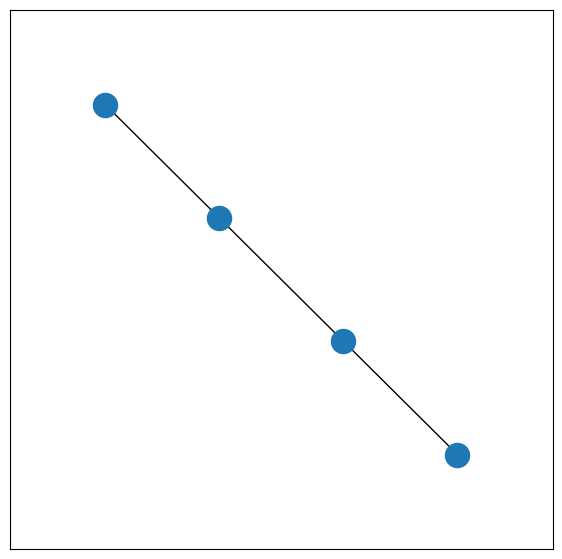

In [32]:
# Let's try just plotting the graph itself
visualize_graph(pyg_graph)

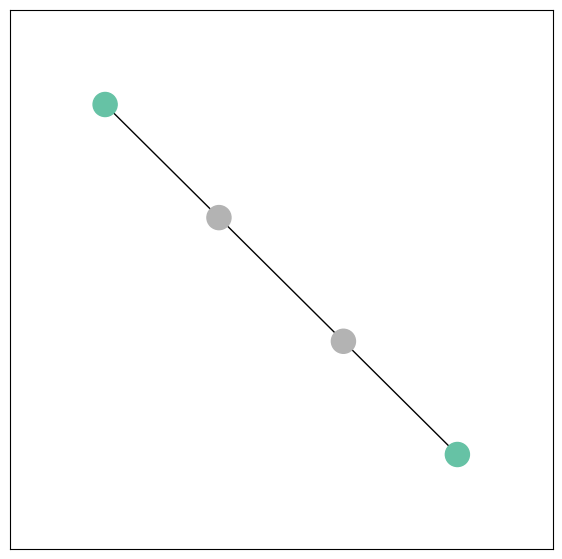

In [33]:
# Now let's color the nodes by the degree
visualize_graph(pyg_graph, deg)

### Optional Exercise: Make your own graph!

Come up with your own graph, and draw this by hand (something up to 8 nodes). Write the `edge_index` corresponding to your graph, then analyze and plot it using the above functions. Do you get what you expect?

### Exercise 1c: Neighbourhood aggregation by hand

This exercise is the key to understanding what a graph neural network does.

Consider a small graph with 4 nodes, each carrying a 2-dimensional feature vector. We'll see what happens when we multiply the feature matrix by the adjacency matrix — this is the operation at the heart of every GNN layer.

Let's use the triangle graph on $\{0,1,2\}$ with an isolated node $3$:

In [34]:
# Triangle on {0,1,2}, isolated node 3
edge_index_tri = torch.tensor([
    [0, 1, 0, 2, 1, 2, 1, 0, 2, 0, 2, 1],
    [1, 0, 2, 0, 2, 1, 0, 1, 0, 2, 1, 2],
], dtype=torch.long)

# Node features: each node has a 2d feature vector
X = torch.tensor([
    [1.0, 0.0],   # node 0
    [0.0, 1.0],   # node 1
    [2.0, 2.0],   # node 2
    [5.0, 5.0],   # node 3 (isolated)
])

A = edge_index_to_adjacency(edge_index_tri, 4)
print("Adjacency matrix:")
print(A)
print()
print("Feature matrix X:")
print(X)

Adjacency matrix:
tensor([[0., 1., 1., 0.],
        [1., 0., 1., 0.],
        [1., 1., 0., 0.],
        [0., 0., 0., 0.]])

Feature matrix X:
tensor([[1., 0.],
        [0., 1.],
        [2., 2.],
        [5., 5.]])


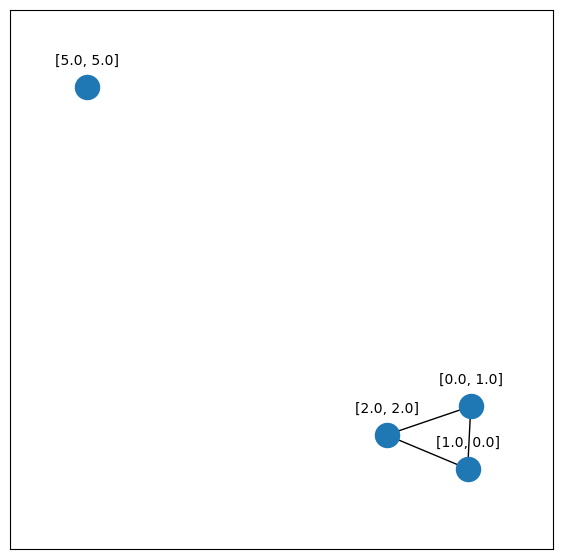

In [35]:
# Plot this graph
pyg_graph = Data(edge_index=edge_index_tri, num_nodes=4)
visualize_graph(pyg_graph, labels = X)

**Exercise:** Compute the product $AX$. Before running the code, try to predict what $AX$ will be. What does row $v$ of $AX$ represent? After you've computed it, plot your graph again with the new labels.

tensor([[2., 3.],
        [3., 2.],
        [1., 1.],
        [0., 0.]])


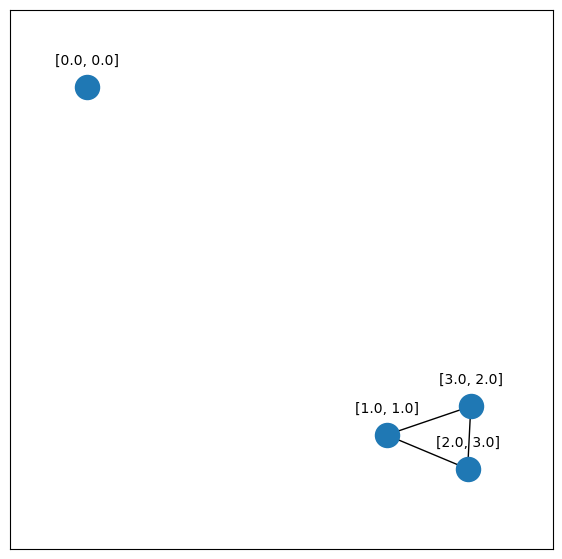

In [37]:
AX = torch.matmul(A,X)
print(AX)

visualize_graph(pyg_graph, labels = AX)

Now let's see what happens when we normalise. The GCN uses the **symmetric normalisation** $\tilde{D}^{-1/2}\tilde{A}\tilde{D}^{-1/2}$, where $\tilde{A} = A + I$ (add self-loops) and $\tilde{D}$ is the degree matrix of $\tilde{A}$.

**Exercise:** Compute $\tilde{A}$, $\tilde{D}$, and the normalised aggregation $\tilde{D}^{-1/2}\tilde{A}\tilde{D}^{-1/2} X$. Compare the result with $AX$. Can you explain in words what the normalised aggregation is computing? Plot the graph again with the new features. (Due to small numerical errors, it may help to first round your features using `torch.round()`.)

In [65]:
# EXERCISE: fill in the steps below

# Step 1: Add self-loops
A_tilde = A + torch.eye(4)

# Step 2: Compute the degree matrix of A_tilde
D_tilde = torch.sum(A_tilde,0) # not a diagonal matrix yet, do that in the next step

# Step 3: Compute D_tilde^{-1/2}
D_tilde_inv_sqrt = torch.diag(torch.pow(D_tilde,-0.5))

# # Step 4: Compute the normalised adjacency
A_norm = torch.matmul(torch.matmul(D_tilde_inv_sqrt, A_tilde),D_tilde_inv_sqrt)

# Step 5: Apply to X
result = torch.matmul(A_norm,X)
result = torch.round(result)

print("A_tilde (adjacency with self-loops):")
print(A_tilde)
print()
print("Normalised aggregation:")
print(result)

expected_result = torch.tensor([[1,1],[1,1],[1,1],[5,5]], dtype=torch.float64)

assert torch.equal(result,expected_result), f"Expected {expected_result}"
print("Test passed!")

A_tilde (adjacency with self-loops):
tensor([[1., 1., 1., 0.],
        [1., 1., 1., 0.],
        [1., 1., 1., 0.],
        [0., 0., 0., 1.]])

Normalised aggregation:
tensor([[1., 1.],
        [1., 1.],
        [1., 1.],
        [5., 5.]])
Test passed!


### The Cora dataset

Now let's work with a real graph. **Cora** is a citation network of 2708 machine learning papers, each classified into one of 7 topics. Each paper has a 1433-dimensional binary (bag-of-words) feature vector. In particular, a collection of 1433 words are fixed, and for each paper (node), the feature vector records whether each word appears in the paper (value set to `1`) or not (value set to `0`). Two papers are connected if one cites the other.

This is a standard benchmark for **node classification**: given the graph structure and node features, predict the class label of each node.

In [66]:
from torch_geometric.datasets import Planetoid

dataset = Planetoid(root='./data/Cora', name='Cora')
data = dataset[0]  # Cora has a single graph

print(f"Number of nodes: {data.num_nodes}")
print(f"Number of edges: {data.num_edges}")
print(f"Number of node features: {data.num_node_features}")
print(f"Number of classes: {dataset.num_classes}")
print(f"Has isolated nodes: {data.has_isolated_nodes()}")
print(f"Has self-loops: {data.has_self_loops()}")
print(f"Is undirected: {data.is_undirected()}")

Processing...
C:\Users\3010295H\AppData\Local\anaconda3\envs\agq-env\Lib\site-packages\torch_geometric\io\planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(f, encoding='latin1')
C:\Users\3010295H\AppData\Local\anaconda3\envs\agq-env\Lib\site-packages\torch_geometric\io\planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(f, encoding='latin1')
C:\Users\3010295H\AppData\Local\anaconda3\envs\agq-env\Lib\site-packages\torch_geometric\io\planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(

Number of nodes: 2708
Number of edges: 10556
Number of node features: 1433
Number of classes: 7
Has isolated nodes: False
Has self-loops: False
Is undirected: True


Done!


In [67]:
# Let's inspect the data object
print("Node feature matrix shape:", data.x.shape)       # (2708, 1433)
print("Edge index shape:", data.edge_index.shape)        # (2, num_edges)
print("Labels shape:", data.y.shape)                     # (2708,)
print()
print("Train/val/test masks (these define the data split):")
print(f"  Train nodes: {data.train_mask.sum().item()}")
print(f"  Val nodes:   {data.val_mask.sum().item()}")
print(f"  Test nodes:  {data.test_mask.sum().item()}")

Node feature matrix shape: torch.Size([2708, 1433])
Edge index shape: torch.Size([2, 10556])
Labels shape: torch.Size([2708])

Train/val/test masks (these define the data split):
  Train nodes: 140
  Val nodes:   500
  Test nodes:  1000


Let's recall what these three sets of data will be used for:
- `train`: These nodes are used to train the model given some task. We assume that we know the labels of these nodes, and can be used during training to optimize our loss function.
- `validation`/`val`: We assume that we know the labels of these nodes, but this information is "held out" during training. We do **not** use these labels to optimize our loss function. Instead, the validation set can be used to help us evaluate how well our model is doing on "unseen" samples. This can be used to choose hyperparameters such as the number of layers or dimensions of hidden dimensions to see what works "best".
- `test`: We assume that we **do not** know the labels of these nodes. Our goal is to predict the labels of these nodes. We should not use the test labels for anything other than computing an accuracy at the very end. In particular, we cannot use this to tune hyperparameters.

For the Cora dataset, these splits are given using **masks**: a binary array (True/False) which tells us whether each node is in a certain split. We can use this recover only the labels from each split.

In [68]:
# The train_mask consists of True/False values
print(data.train_mask)

# We can use this to mask the labels
print(data.y[data.train_mask])

# For instance, let's compare the length of all labels, with the length of the masked labels
print(f"\nTotal number of labels: {len(data.y)}")
print(f"Total number of masked labels: {len(data.y[data.train_mask])}")

tensor([ True,  True,  True,  ..., False, False, False])
tensor([3, 4, 4, 0, 3, 2, 0, 3, 3, 2, 0, 0, 4, 3, 3, 3, 2, 3, 1, 3, 5, 3, 4, 6,
        3, 3, 6, 3, 2, 4, 3, 6, 0, 4, 2, 0, 1, 5, 4, 4, 3, 6, 6, 4, 3, 3, 2, 5,
        3, 4, 5, 3, 0, 2, 1, 4, 6, 3, 2, 2, 0, 0, 0, 4, 2, 0, 4, 5, 2, 6, 5, 2,
        2, 2, 0, 4, 5, 6, 4, 0, 0, 0, 4, 2, 4, 1, 4, 6, 0, 4, 2, 4, 6, 6, 0, 0,
        6, 5, 0, 6, 0, 2, 1, 1, 1, 2, 6, 5, 6, 1, 2, 2, 1, 5, 5, 5, 6, 5, 6, 5,
        5, 1, 6, 6, 1, 5, 1, 6, 5, 5, 5, 1, 5, 1, 1, 1, 1, 1, 1, 1])

Total number of labels: 2708
Total number of masked labels: 140


### Exercise 1d: Analyze the Cora graph

**Exercise**: Use the `compute_degrees()` function you wrote before to analyze the Cora graph. Compute the minimum, maximum, and mean degrees of Cora. 

In [72]:
# EXERCISE: Use compute_degrees on the Cora edge index
cora_degrees = compute_degrees(data.edge_index)
print(f"Min degree: {torch.min(cora_degrees)}\nMax degree: {torch.max(cora_degrees)}\nMean degree: {torch.mean(cora_degrees.to(float))}")

Min degree: 1
Max degree: 168
Mean degree: 3.8980797636632203


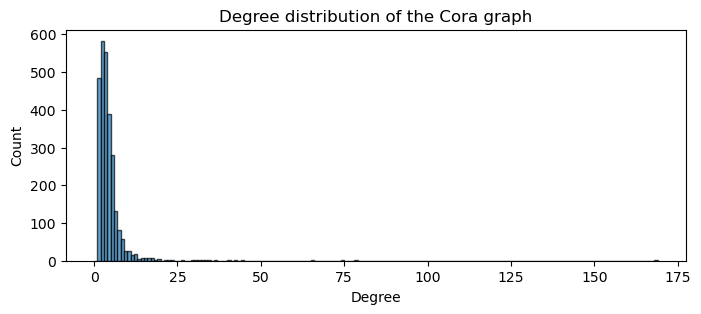

In [73]:
# We can also plot the distribution of degrees on the graph
plt.figure(figsize=(8, 3))
plt.hist(cora_degrees.numpy(), bins=range(0, cora_degrees.max().item() + 2), 
         edgecolor='black', alpha=0.7)
plt.xlabel("Degree")
plt.ylabel("Count")
plt.title("Degree distribution of the Cora graph")
plt.show()

---
## Part 2: Node Classification on Cora

The task: predict the topic label of each paper using its features and the graph structure.

We will first try an **MLP** (multi-layer perceptron; this was also called a DNN in previous lecture) that ignores the graph entirely and uses only the node features. Then we will build a **GCN** (graph convolutional network) that also uses the graph structure. Comparing the two will show us what the graph buys us.

### 2.1 Building the MLP

First, let's write an MLP model. While we could write this using the nn.Sequential method as was done in a previous lecture, we will do this manually here (which we'll need to do for the later GNN model). The reason for doing so is that nn.Sequential assumes that the model is built from a sequence of layers which take exactly one input, and returns exactly one output, which is passed directly into the next layer. For GNN layers, one needs to also input the graph connectivity.

### Exercise 2.a: Build the MLP

In [75]:
# EXERCISE: Build the MLP

class MLP(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.fc1 = nn.Linear(in_channels, hidden_channels) ##FINISH ME##
        self.fc2 = nn.Linear(hidden_channels, out_channels) ##FINISH ME##
    
    def forward(self, x, edge_index):
        # edge_index is unused — the MLP ignores graph structure
        x = self.fc1(x) # apply first linear layer fc1 
        x = F.relu(x)  # apply a relu nonlinearity
        x = self.fc2(x)  # apply the second linear layer fc2
        return x

mlp = MLP(dataset.num_node_features, 64, dataset.num_classes)
print(mlp)

MLP(
  (fc1): Linear(in_features=1433, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=7, bias=True)
)


In [76]:
# For later comparison, we want to know how many parameters we are using in this model
print(f"\nNumber of parameters: {sum(p.numel() for p in mlp.parameters())}")


Number of parameters: 92231


### 2.2 Train and Evaluation Loop

Here, we will provide most of the function which performs the train/evaluation loop. This is similar to the loop that you wrote during the DNN workshop.  

**A remark on fair comparisons.** When comparing neural network architectures, we should keep the comparison fair: same number of training epochs, similar number of parameters, same optimiser settings, etc. The point is to isolate the effect of the architectural choice (graph structure vs. no graph structure), not to show that one model was trained better than another. Writing a single train/evaluation function, which we will use for both models, is a good way of keeping things consistent.

### Exercise 2b: Fill in the line with the loss function

In [83]:
def train_and_evaluate(model, data, lr=0.01, weight_decay=5e-4, epochs=200, verbose=True):
    """
    Train a model on the Cora node classification task and return test accuracy.
    
    Args:
        model: a torch.nn.Module that takes (data.x, data.edge_index) and returns 
               logits of shape (num_nodes, num_classes)
        data: the Cora PyG data object
        lr: learning rate
        weight_decay: L2 regularisation strength
        epochs: number of training epochs
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        
        # Forward pass
        # Note: This should work for both the MLP and the GCN, so we pass in the data.edge_index variable
        # even though this is not used for the MLP (this is also why we include edge_index as an input
        # in the forward() function of the MLP)
        out = model(data.x, data.edge_index)

        # EXERCISE: Fill in the rest of this function
        # We want to compare the output of our model with the true labels (in data.y) but ONLY using
        # the training split. How do we do this (look at "The Cora Dataset" section above)?
        loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
            
        loss.backward()                         # compute gradients
        optimizer.step()                        # update weights
        
        # Display progress every 50 epochs
        if verbose and (epoch + 1) % 50 == 0:
            # Evaluate on validation set
            model.eval()
            with torch.no_grad():
                pred = model(data.x, data.edge_index).argmax(dim=1)
                val_acc = (pred[data.val_mask] == data.y[data.val_mask]).float().mean()
            print(f"Epoch {epoch+1:3d} | Loss: {loss.item():.4f} | Val acc: {val_acc:.4f}")
            model.train()
    
    # Final test accuracy
    model.eval()
    with torch.no_grad():
        pred = model(data.x, data.edge_index).argmax(dim=1)
        test_acc = (pred[data.test_mask] == data.y[data.test_mask]).float().mean()
    
    return test_acc.item()

### 2.3 Baseline Experiment: MLP

Now, let's use the MLP to train and evaluate our model.

In [84]:
mlp_acc = train_and_evaluate(mlp, data)
print(f"\nMLP test accuracy: {mlp_acc:.4f}")

Epoch  50 | Loss: 0.0019 | Val acc: 0.4960
Epoch 100 | Loss: 0.0056 | Val acc: 0.5560
Epoch 150 | Loss: 0.0049 | Val acc: 0.5460
Epoch 200 | Loss: 0.0043 | Val acc: 0.5440

MLP test accuracy: 0.5760


You should see something in the range of 55–60%. Not terrible, but the MLP is leaving information on the table by ignoring the graph.


### 2.3 The Graph Convolutional Network (GCN)

The GCN layer, introduced by Kipf & Welling (2017), is defined by the update rule:

$$\mathbf{h}_v^{(\ell+1)} = \sigma\!\left( \sum_{u \in \mathcal{N}(v) \cup \{v\}} \frac{1}{\sqrt{\deg(u)\,\deg(v)}} \, W^{(\ell)} \mathbf{h}_u^{(\ell)} \right)$$

where $\mathcal{N}(v)$ denotes the neighbours of $v$ (the self-loop $\{v\}$ is added explicitly), $\deg$ denotes the degree in the augmented graph (i.e., including the self-loop), and $W^{(\ell)}$ is a learnable weight matrix.

### Exercise 2c: Implement a GCN layer

PyTorch Geometric provides a `MessagePassing` base class. To implement a layer, you need to:
1. In `forward`: add self-loops, compute normalisation coefficients (the $\frac{1}{\sqrt{\deg(u)\,\deg(v)}}$ above), then call `self.propagate`.
2. In `message`: define what message each edge carries (here: applies the normalization to each linearly transformed feature)

The `propagate` method orchestrates the message passing: it calls `message` for each edge, aggregates messages at each target node (using the aggregation specified in `__init__`, here `'add'`), and returns the result.

Recall that operations are performed using `edge_index` (an array of edges, rather than an adjacency matrix).

Fill in the missing lines below.    

**Note:** For additional help, take a look at the [PyG Tutorial on Creating GNNs](https://pytorch-geometric.readthedocs.io/en/latest/tutorial/create_gnn.html)

In [87]:
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import add_self_loops, degree

class GCNConv(MessagePassing):
    def __init__(self, in_channels, out_channels):
        super().__init__(aggr='add')  # "add" aggregation (sum over neighbours)
        self.lin = nn.Linear(in_channels, out_channels, bias=False)
        self.bias = nn.Parameter(torch.zeros(out_channels))
    
    def forward(self, x, edge_index):
        # Step 1: Add self-loops to the edge index.
        edge_index, _ = add_self_loops(edge_index, num_nodes=x.size(0))

        # Step 2: Linearly transform the node features.
        # EXERCISE: fill in
        x = self.lin(x)
        
        # Step 3: Compute the normalisation.
        #   For each edge (u, v), we need 1/sqrt(deg(u) * deg(v)).
        #   Here row = source nodes, col = target nodes.
        # EXERCISE: Construct a size (num_edges,) array `norm`` such that norm[i] = 1/sqrt(deg(edge_index[0,i]) * deg(edge_index[0,i])).
        row, col = edge_index
        deg = degree(col, x.size(0), dtype=x.dtype)
        deg_inv_sqrt = deg.pow(-0.5)
        deg_inv_sqrt[deg_inv_sqrt == float('inf')] = 0  # handle isolated nodes with deg=0
        norm = deg_inv_sqrt[row] * deg_inv_sqrt[col] # This should be a 1D array of the same length as edge_index
        
        # Step 4: Call propagate. This calls self.message() on each edge,
        #   then aggregates (sums) messages at each target node.
        out = self.propagate(edge_index, x=x, norm=norm)
        
        return out + self.bias
    
    def message(self, x_j, norm):
        # x_j has shape (num_edges, out_channels): the source node features for each edge.
        # norm has shape (num_edges,): the normalisation coefficient for each edge.
        
        # EXERCISE: return the normalised message
        return norm.view(-1, 1) * x_j


### Exercise 2d: Build a 2-layer GCN

Now use your `GCNConv` layer to build a 2-layer GCN for node classification, analogous to the MLP above. The architecture should be:

$$\text{Input} \xrightarrow{\text{GCNConv}} \text{ReLU}\xrightarrow{\text{GCNConv}} \text{Output}$$

In [92]:
class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        # EXERCISE: define two GCNConv layers
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
    
    def forward(self, x, edge_index):
        # EXERCISE: implement the forward pass
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        # Apply conv1, then ReLU, then dropout (p=0.5), then conv2
        return x

In [93]:
gcn = GCN(dataset.num_node_features, 64, dataset.num_classes)
print(gcn)
print(f"\nNumber of parameters: {sum(p.numel() for p in gcn.parameters())}")

GCN(
  (conv1): GCNConv()
  (conv2): GCNConv()
)

Number of parameters: 92231


In [94]:
gcn_acc = train_and_evaluate(gcn, data)
print(f"\nGCN test accuracy: {gcn_acc:.4f}")

Epoch  50 | Loss: 0.0142 | Val acc: 0.7740
Epoch 100 | Loss: 0.0140 | Val acc: 0.7740
Epoch 150 | Loss: 0.0130 | Val acc: 0.7780
Epoch 200 | Loss: 0.0117 | Val acc: 0.7780

GCN test accuracy: 0.8080


In [95]:
# Comparison between MLP and GCN
print(f"\n{'='*40}")
print(f"Number of parameters (MLP): {sum(p.numel() for p in mlp.parameters())}")
print(f"Number of parameters (GCN): {sum(p.numel() for p in gcn.parameters())}")
print(f"\n{'='*40}")
print(f"MLP test accuracy: {mlp_acc:.4f}")
print(f"GCN test accuracy: {gcn_acc:.4f}")
print(f"{'='*40}")
print(f"\nImprovement from using graph structure: {gcn_acc - mlp_acc:+.4f}")


Number of parameters (MLP): 92231
Number of parameters (GCN): 92231

MLP test accuracy: 0.5760
GCN test accuracy: 0.8080

Improvement from using graph structure: +0.2320


You should see the GCN achieving roughly 80% accuracy — a significant improvement over the MLP. The graph structure provides useful information: a paper's topic is correlated with the topics of the papers it cites.

**Discussion.** The GCN has a 2-hop receptive field (each node sees its 2-neighbourhood after 2 layers). What would happen with more layers? In principle you'd capture longer-range dependencies, but in practice deep GCNs suffer from **oversmoothing**: all node representations converge to the same vector. This is an active area of research.


### Exercise 2e (Optional): Layers and Parameters

What happens when we change the number of hidden parameters or number of layers? Does this change the performance?    

---
## Part 3: Graph Regression on ZINC

So far we've done **node classification** on a single large graph. Now we turn to **graph regression**: we have a dataset of many small graphs, each with a real valued parameter, and our aim is to estimate this parameter.

We'll use **ZINC**, a dataset of ~12,000 molecular graphs. Each node is an atom (encoded as a categorical feature), each edge is a bond, and the task is to predict a molecular property (a real number).    

For further details about the data set, see here: [ZINC Dataset](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.datasets.ZINC.html)

**NOTE:** Because this is a larger dataset, we will start by restricting the training set to 1000 graphs (so that this can train fairly quickly on laptops). Once you get this section working, you can try to increase `num_training_graphs` (on my laptop it takes ~5 minutes to train using the full 12000 graphs)

### 3.1 Loading ZINC

In [ ]:
from torch_geometric.datasets import ZINC

train_dataset_full = ZINC(root='./data/ZINC', subset=True, split='train')
val_dataset = ZINC(root='./data/ZINC', subset=True, split='val')
test_dataset = ZINC(root='./data/ZINC', subset=True, split='test')

# We further restrict the train_dataset on our first attempt
num_training_graphs = 1000
train_dataset = train_dataset_full[:num_training_graphs]

print(f"Training graphs:   {len(train_dataset)}")
print(f"Validation graphs: {len(val_dataset)}")
print(f"Test graphs:       {len(test_dataset)}")
print()

# Inspect one graph
g = train_dataset[0]
print(f"Example graph: {g}")
print(f"  Nodes: {g.num_nodes}, Edges: {g.num_edges}")
print(f"  Node features (x): {g.x.shape}  (categorical atom types)")
print(f"  Target (y): {g.y.item():.4f}  (a real number)")

### Exercise 3a: Visualizing the dataset

**Exercise:** Let's visualize some of the graphs. Here, the node features are just integer labels (representing different types of atoms), so we can use the `color` input in `visualize_graph()` to visualize this.

In [ ]:
# EXERCISE
# Plot some of the graphs in the dataset

### 3.2 Batching: how to process many graphs at once

In node classification, we had one big graph and processed it whole. For graph classification, we have thousands of small graphs and need to process them in **batches**.

PyG's approach is elegant: a batch of graphs is represented as a **single large disconnected graph**. If we batch graphs $G_1, G_2, \ldots, G_k$, the result is one graph whose adjacency matrix is block-diagonal:

$$A_{\text{batch}} = \begin{pmatrix} A_1 & & \\ & A_2 & \\ & & \ddots \end{pmatrix}$$

A `batch` vector records which node belongs to which original graph, enabling us to compute per-graph outputs.

In [ ]:
from torch_geometric.loader import DataLoader

batch_size = 3

# Create a small batch
loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
batch = next(iter(loader))

print(f"Batch object: {batch}")
print(f"Total nodes in batch: {batch.num_nodes}")
print(f"Total edges in batch: {batch.num_edges}")
print(f"Batch vector shape: {batch.batch.shape}")
print(f"Batch vector (first 30): {batch.batch[:30]}")
print(f"Targets: {batch.y}")

# The batch vector tells us which graph each node belongs to.
# Let's check: how many nodes in each graph?
for i in range(batch_size):
    n_i = (batch.batch == i).sum().item()
    print(f"  Graph {i}: {n_i} nodes")

Let's visualize the batch, and color by which graph each node belongs to. Try adjusting batch size, or loading different batches to see what is going on

In [ ]:
# Let's visualize the batch, and color by which graph each node belongs to
# (Note that the plotting function will sometimes overlap different graphs)
visualize_graph(batch, color=batch.batch)

### 3.3 Graph-level readout

For graph classification/regression, we need to go from node-level representations to a single graph-level representation. The simplest approach: **mean pooling** — average the node features within each graph.

PyG provides `global_mean_pool(x, batch)` which does exactly this.

### Exercise 3b: Build a GCN for graph regression

Adapt the GCN architecture for graph-level prediction:
1. Use an **embedding layer** (`nn.Embedding`) to convert the categorical (integer) atom types to dense vectors.
2. Apply GCN layers (you can use `torch_geometric.nn.GCNConv` now — the one from the library).
3. Apply global mean pooling.
4. Apply a final linear layer to produce a single output (the predicted property).

Since this is regression, we'll use mean squared error (MSE) loss instead of cross-entropy.

In [ ]:
from torch_geometric.nn import GCNConv as PyG_GCNConv  # use the library version of GCNConv
from torch_geometric.nn import global_mean_pool

class GraphGCN(nn.Module):
    def __init__(self, num_atom_types, hidden_channels):
        super().__init__()
        # ZINC node features are categorical atom types — embed them
        self.emb = nn.Embedding(num_atom_types, hidden_channels)
        
        # EXERCISE: define GCN layers
        # self.conv1 = ...
        # self.conv2 = ...
        # self.conv3 = ...

        # Final linear layer should output a single number
        self.lin = nn.Linear(hidden_channels, 1)  
    
    def forward(self, x, edge_index, batch):
        # Step 1: Embed atom types
        # x has shape (total_nodes, 1) with integer atom types
        x = self.emb(x.squeeze(-1))  # -> (total_nodes, hidden_channels)
        
        # EXERCISE: apply GCN layers with ReLU activations
        # x = ...
        # x = ...
        # x = ...
        
        # Step 2: Global mean pooling (average over nodes in each graph)
        x = global_mean_pool(x, batch)  # -> (num_graphs_in_batch, hidden_channels)
        
        # Step 3: Final linear layer
        # EXERCISE:
        # x = ...
        
        return x.squeeze(-1)  # -> (num_graphs_in_batch,)

In [ ]:
# Train and evaluation functions for ZINC dataset
def train_zinc(model, train_loader, val_loader, epochs=100, lr=0.001):
    """Train a graph-level regression model on ZINC."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in train_loader:
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index, batch.batch)
            loss = F.mse_loss(out, batch.y.float())
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * batch.num_graphs
        train_loss = total_loss / len(train_loader.dataset)
        
        if (epoch + 1) % 25 == 0:
            val_loss = evaluate_zinc(model, val_loader)
            print(f"Epoch {epoch+1:3d} | Train MAE: {train_loss:.4f} | Val MAE: {val_loss:.4f}")
    
    return model

def evaluate_zinc(model, loader):
    model.eval()
    total_error = 0
    with torch.no_grad():
        for batch in loader:
            out = model(batch.x, batch.edge_index, batch.batch)
            total_error += (out - batch.y.float()).abs().sum().item()
    return total_error / len(loader.dataset)

In [ ]:
# Determine the number of distinct atom types in ZINC
max_atom_type = max(d.x.max().item() for d in train_dataset)
num_atom_types = max_atom_type + 1
print(f"Number of atom types: {num_atom_types}")

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

model = GraphGCN(num_atom_types, hidden_channels=64)
print(model)
print(f"\nNumber of parameters: {sum(p.numel() for p in model.parameters())}")

In [ ]:
# Run model
model = train_zinc(model, train_loader, val_loader, epochs=100)
test_mae = evaluate_zinc(model, test_loader)
print(f"\nTest MAE: {test_mae:.4f}")

In [ ]:
# Collect predictions and true values on the test set
model.eval()
all_preds = []
all_targets = []
with torch.no_grad():
    for batch in test_loader:
        out = model(batch.x, batch.edge_index, batch.batch)
        all_preds.append(out)
        all_targets.append(batch.y.float())

all_preds = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()

Let's plot our results.

In [ ]:
# Plot our results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: predicted vs true scatter plot
ax = axes[0]
ax.scatter(all_targets, all_preds, alpha=0.3, s=10, edgecolors='none')
# Plot y = x line for reference
lo = min(all_targets.min(), all_preds.min())
hi = max(all_targets.max(), all_preds.max())
ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1, label='perfect predictions')
ax.set_xlabel("True value")
ax.set_ylabel("Predicted value")
ax.set_title("Predicted vs True (test set)")
ax.legend()
ax.set_aspect('equal')

# Right: residual histogram
ax = axes[1]
residuals = all_preds - all_targets
ax.hist(residuals, bins=50, edgecolor='black', alpha=0.7)
ax.axvline(0, color='k', linestyle='--', linewidth=1)
ax.set_xlabel("Residual (predicted − true)")
ax.set_ylabel("Count")
ax.set_title("Residual distribution (test set)")

plt.tight_layout()
plt.show()

### Additional Tasks (if time permits)

1) In Part 3, try increasing the number of graphs in the training set. How much does the regression improve?
2) In either Part 2 or Part 3, try changing the network: number of layers, dimension of hidden layers, or even changing the type of GNN layer (other standard choices are [GINConv](https://pytorch-geometric.readthedocs.io/en/2.7.0/generated/torch_geometric.nn.conv.GINConv.html#torch_geometric.nn.conv.GINConv) and [GATConv](https://pytorch-geometric.readthedocs.io/en/2.7.0/generated/torch_geometric.nn.conv.GATConv.html#torch_geometric.nn.conv.GATConv)).